# Probability Distribution

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import bernoulli
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import uniform

## Bernoulli Distribution
    A Bernoulli Distribution is the simplest discrete probability distribution.

    It models an experiment that consists of only one trial with two possible outcomes.

    The outcomes are represented as:
        - Success (1)
        - Failure (0)

    The probability of success is denoted by p, while the probability of failure is 1 − p.

    A Bernoulli Distribution can be used only when the following conditions are satisfied:
        - Only one trial is performed.
        - There are only two possible outcomes.
        - The outcomes are mutually exclusive.
        - The probability of success remains constant.
        - The probability of failure is equal to 1 − p.


## Formula

            Probability of Success

$$
P(X=1)=p
$$

            Probability of Failure

$$
P(X=0)=1-p
$$

            Where
                - p= Probability of Success
                - 1-p = Probability of Failure

### Manual Example

            Suppose a customer visits an online shopping website.

            Possible outcomes are:

| Outcome | Value |
|----------|------|
| Purchased Product | 1 |
| Did Not Purchase | 0 |

            Suppose,

            Probability of Purchase = 0.70
            Then,

            Probability of Not Purchasing

$$
1-0.70=0.30
$$
            
            Therefore,

| Outcome | Probability |
|----------|-------------|
|Purchase|0.70|
|No Purchase|0.30|

In [3]:
Purchase = pd.DataFrame({

    "Customer_ID": range(1,21),

    "Purchased": [
        1,0,1,1,0,
        1,1,0,1,0,
        1,1,0,0,1,
        1,0,1,1,0
    ]

})

Purchase

,Customer_ID,Purchased
0,1,1
1,2,0
2,3,1
3,4,1
4,5,0
5,6,1
6,7,1
7,8,0
8,9,1
9,10,0


In [4]:
Purchase["Purchased"].value_counts()

Purchased
1    12
0     8
Name: count, dtype: int64

In [5]:
Purchase["Purchased"].value_counts(normalize=True)

Purchased
1    0.6
0    0.4
Name: proportion, dtype: float64

In [19]:
p = 0.60

print("Probability of Success")

print(bernoulli.pmf(1,p))

print()

f=bernoulli.pmf(0,p)
print(f"Probability of Failure:\n{f:.1f}")



Probability of Success
0.6

Probability of Failure:
0.4


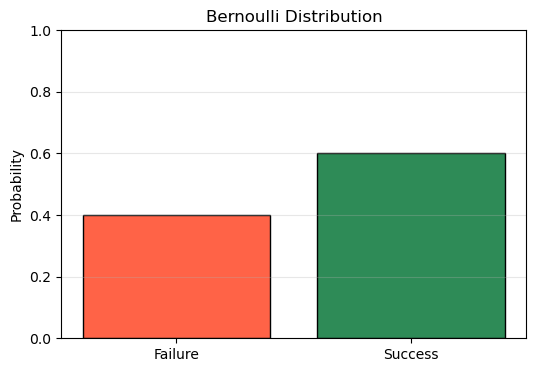

In [20]:
x=[0,1]

prob=bernoulli.pmf(x,p)

plt.figure(figsize=(6,4))

plt.bar(

    ["Failure","Success"],

    prob,

    color=["tomato","seagreen"],

    edgecolor="black"

)

plt.ylim(0,1)

plt.ylabel("Probability")

plt.title("Bernoulli Distribution")

plt.grid(axis="y",alpha=.3)

plt.show()

### Binomial Distribution
    A Binomial Distribution is a discrete probability distribution that describes the probability of obtaining a fixed number of successes in a fixed number of independent Bernoulli trials.

    Each trial has only two possible outcomes:
        - Success (1)
        - Failure (0)

    The probability of success remains constant in every trial.

    

### Formula
    The probability of getting exactly x successes in n trials is

$$
P(X=x)=\binom{n}{x}p^x(1-p)^{n-x}
$$

    Where,
        - n = Number of trials
        - x = Number of successes
        - p = Probability of success
        - 1-p = Probability of failure
    
# Mean and Variance
                    Mean

$$
\mu=np
$$

                    Variance

$$
\sigma^2=np(1-p)
$$

                    Standard Deviation

$$
\sigma=\sqrt{np(1-p)}
$$

### PMF
    'binom.pmf(x,n,p)'

    Returns the probability of getting **exactly x successes**.

    Example:-Exactly 4 customers purchase.

In [21]:
# Parameters
n = 10
p = 0.40
x = 4

probability = binom.pmf(x,n,p)

print(f"Probability = {probability:.4f}")

Probability = 0.2508


In [22]:
n = 10
p = 0.40

mean = n*p

variance = n*p*(1-p)

std = np.sqrt(variance)

print("Mean :",mean)

print("Variance :",variance)

print("Standard Deviation :",std)

Mean : 4.0
Variance : 2.4
Standard Deviation : 1.5491933384829668


In [30]:
x=np.arange(0,n+1)

prob=binom.pmf(x,n,p)

binomial_df=pd.DataFrame({

    "Successes":x,

    "Probability":prob

})

binomial_df.head()

,Successes,Probability
0,0,0.006047
1,1,0.040311
2,2,0.120932
3,3,0.214991
4,4,0.250823


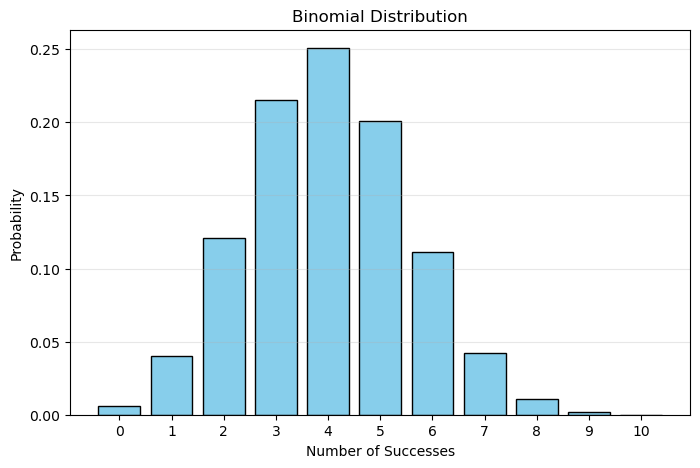

In [24]:
plt.figure(figsize=(8,5))

plt.bar(

    x,

    prob,

    color="skyblue",

    edgecolor="black"

)

plt.title("Binomial Distribution")

plt.xlabel("Number of Successes")

plt.ylabel("Probability")

plt.xticks(x)

plt.grid(axis="y",alpha=.3)

plt.show()

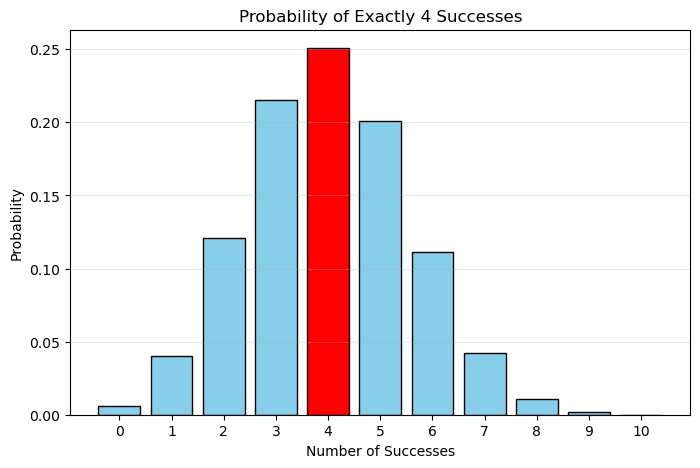

In [25]:
colors=["skyblue"]*len(x)

colors[4]="red"

plt.figure(figsize=(8,5))

plt.bar(x,prob,color=colors,edgecolor="black")

plt.title("Probability of Exactly 4 Successes")

plt.xlabel("Number of Successes")

plt.ylabel("Probability")

plt.xticks(x)

plt.grid(axis="y",alpha=.3)

plt.show()

### CDF
    'binom.cdf(x,n,p)'

    Returns the probability of getting x or fewer successes.

    Example:- At most 4 customers purchase.(<=4)


In [26]:
prob = binom.cdf(4,n,p)

print(prob)

0.6331032576


### Survival Function

    '1-binom.cdf(x-1,n,p)'

    Returns the probability of getting x or more successes.
    
    Example
        At least 4 customers purchase.

In [27]:
prob=1-binom.cdf(3,n,p)

print(prob)

0.6177193984000001


### Poisson Distribution

    A Poisson Distribution is a discrete probability distribution that describes the probability of a given number of events occurring in a fixed interval of "time, area, distance, or volume", provided that:

        - Events occur independently.
        - Events occur at a constant average rate.
        - Two events cannot occur at exactly the same instant.



### Formula
    The probability of observing exactly x events is

$$
P(X=x)=\frac{e^{-\lambda}\lambda^x}{x!}
$$

    Where,
        - x = Number of events
        - λ (lambda)** = Average number of events
        - e = Euler's constant (≈ 2.718)

---

### Mean

$$
\mu=\lambda
$$

### Variance

$$
\sigma^2=\lambda
$$



### X Value Should Exact 
    Use pmf Calc Prob

In [28]:
# Average number of orders
lam = 8

# Exactly 10 orders
x = 10

prob = poisson.pmf(x, lam)

print(f"Probability = {prob:.4f}")

Probability = 0.0993


In [31]:
x = np.arange(0,21)

prob = poisson.pmf(x, lam)

poisson_df = pd.DataFrame({

    "Orders":x,

    "Probability":prob

})

poisson_df.head()

,Orders,Probability
0,0,0.000335
1,1,0.002684
2,2,0.010735
3,3,0.028626
4,4,0.057252


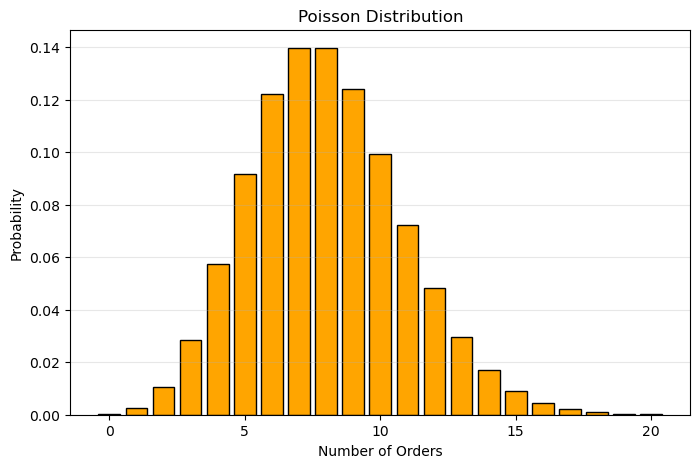

In [33]:
plt.figure(figsize=(8,5))

plt.bar(x,prob,color='orange',edgecolor='black')


plt.title("Poisson Distribution")

plt.xlabel("Number of Orders")

plt.ylabel("Probability")

plt.grid(axis="y",alpha=.3)

plt.show()

### X Value Can Be >= Or <=
    Use cdf for Calc

In [34]:
prob = 1 - poisson.cdf(9, lam)

print(f"P(X ≥ 10) = {prob:.4f}")

P(X ≥ 10) = 0.2834


### Uniform Distribution

    A Uniform Distribution is a probability distribution in which every possible outcome has an equal probability of occurring.

    There are two types of Uniform Distribution:
        1. Discrete Uniform Distribution
        2. Continuous Uniform Distribution

    Examples
        - Rolling a fair die
        - Picking a random card
        - Random number generation
        - Random sampling

### Types of Uniform Distribution

## 1. Discrete Uniform Distribution
    Each discrete value has the same probability.

    Example:Rolling a fair six-sided die.

| Outcome | Probability |
|---------|-------------|
|1|1/6|
|2|1/6|
|3|1/6|
|4|1/6|
|5|1/6|
|6|1/6|

## 2. Continuous Uniform Distribution
    Every value within an interval has the same probability density.
    
    Example:
        Randomly selecting a number between 0 and 100.

In [36]:
a = 0
b = 10

x = np.linspace(a, b, 100)

pdf = uniform.pdf(
    x,
    loc=a,
    scale=b-a
)

uniform_df = pd.DataFrame({ "x":x, "Density":pdf })

uniform_df.head()

,x,Density
0,0.00000,0.1
1,0.10101,0.1
2,0.20202,0.1
3,0.30303,0.1
4,0.40404,0.1


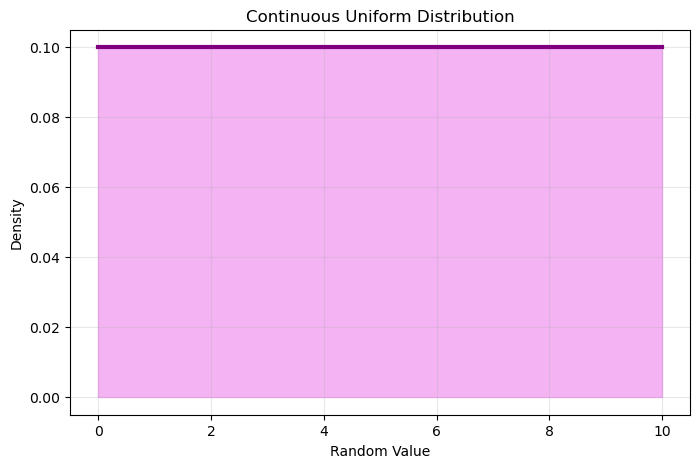

In [49]:
plt.figure(figsize=(8,5))

plt.plot(x,pdf,linewidth=3,color="purple")

plt.fill_between(
    x,
    pdf,
    alpha=0.6,
    color="violet"
)

plt.title("Continuous Uniform Distribution")

plt.xlabel("Random Value")

plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.show()